# Leeds Health Inequalities Project - Main Pipeline

## Configuration

In [1]:

INPUT_FILE = 'File_7_-_All_IoD2019_Scores__Ranks__Deciles_and_Population_Denominators_3.csv'
LOCAL_AUTHORITY = 'Leeds'
OUTPUT_FOLDER = 'output'

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Create output folder
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

print("=" * 80)
print("LEEDS HEALTH INEQUALITIES PROJECT")
print("=" * 80)
print(f"\nInput file: {INPUT_FILE}")
print(f"Output folder: {OUTPUT_FOLDER}")
print(f"Local Authority: {LOCAL_AUTHORITY}")

LEEDS HEALTH INEQUALITIES PROJECT

Input file: File_7_-_All_IoD2019_Scores__Ranks__Deciles_and_Population_Denominators_3.csv
Output folder: output
Local Authority: Leeds


## Step 1: Load and Filter Data

In [2]:
# Load the IMD dataset
print(f"Loading data from {INPUT_FILE}...")

# Try different encodings
encodings = ['utf-8', 'latin-1', 'cp1252']
df = None

for encoding in encodings:
    try:
        df = pd.read_csv(INPUT_FILE, encoding=encoding, low_memory=False)
        print(f"Successfully loaded with {encoding} encoding")
        break
    except (UnicodeDecodeError, FileNotFoundError):
        continue

if df is None:
    raise FileNotFoundError(f"Could not load {INPUT_FILE}. Please check the filename.")

print(f"Dataset shape: {df.shape}")
print(f"Columns: {len(df.columns)}")
df.head()

Loading data from File_7_-_All_IoD2019_Scores__Ranks__Deciles_and_Population_Denominators_3.csv...
Successfully loaded with utf-8 encoding
Dataset shape: (32844, 57)
Columns: 57


,LSOA code (2011),LSOA name (2011),Local Authority District code (2019),Local Authority District name (2019),Index of Multiple Deprivation (IMD) Score,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Score (rate),Income Rank (where 1 is most deprived),Income Decile (where 1 is most deprived 10% of LSOAs),...,Indoors Sub-domain Rank (where 1 is most deprived),Indoors Sub-domain Decile (where 1 is most deprived 10% of LSOAs),Outdoors Sub-domain Score,Outdoors Sub-domain Rank (where 1 is most deprived),Outdoors Sub-domain Decile (where 1 is most deprived 10% of LSOAs),Total population: mid 2015 (excluding prisoners),Dependent Children aged 0-15: mid 2015 (excluding prisoners),Population aged 16-59: mid 2015 (excluding prisoners),Older population aged 60 and over: mid 2015 (excluding prisoners),Working age population 18-59/64: for use with Employment Deprivation Domain (excluding prisoners)
0,E01000001,City of London 001A,E09000001,City of London,6.208,29199,9,0.007,32831,10,...,16364,5,1.503,1615,1,1296,175,656,465,715
1,E01000002,City of London 001B,E09000001,City of London,5.143,30379,10,0.034,29901,10,...,22676,7,1.196,2969,1,1156,182,580,394,620
2,E01000003,City of London 001C,E09000001,City of London,19.402,14915,5,0.086,18510,6,...,17318,6,2.207,162,1,1350,146,759,445,804
3,E01000005,City of London 001E,E09000001,City of London,28.652,8678,3,0.211,6029,2,...,25218,8,1.769,849,1,1121,229,692,200,683
4,E01000006,Barking and Dagenham 016A,E09000002,Barking and Dagenham,19.837,14486,5,0.117,14023,5,...,14745,5,0.969,4368,2,2040,522,1297,221,1285


In [3]:
# Filter for Leeds
print(f"\nFiltering for {LOCAL_AUTHORITY}...")

# Find Local Authority column
la_col = None
possible_names = [
    'Local Authority District name (2019)',
    'Local Authority District (2019)',
    'Local Authority',
    'LA name',
    'LAD19NM'
]

for name in possible_names:
    if name in df.columns:
        la_col = name
        break

if la_col is None:
    print("Available columns:", df.columns.tolist()[:10])
    raise ValueError("Could not find Local Authority column")

print(f"Using column: {la_col}")

# Filter for Leeds
leeds_df = df[df[la_col].str.contains(LOCAL_AUTHORITY, case=False, na=False)].copy()

print(f"Found {len(leeds_df)} LSOAs in {LOCAL_AUTHORITY}")
print(f"Original dataset had {len(df)} LSOAs")

# Clean data types
numeric_patterns = ['Score', 'Rank', 'Decile', 'Population', 'Count', 'Rate', 'Percent']
for col in leeds_df.columns:
    if any(pattern.lower() in col.lower() for pattern in numeric_patterns):
        if 'code' not in col.lower() and 'name' not in col.lower():
            leeds_df[col] = pd.to_numeric(leeds_df[col], errors='coerce')

# Remove duplicates
leeds_df = leeds_df.drop_duplicates()

# Save cleaned data
cleaned_file = os.path.join(OUTPUT_FOLDER, 'Leeds_IMD_LSOA.csv')
leeds_df.to_csv(cleaned_file, index=False)
print(f"\nSaved cleaned data to {cleaned_file}")

leeds_df.head()


Filtering for Leeds...
Using column: Local Authority District name (2019)
Found 482 LSOAs in Leeds
Original dataset had 32844 LSOAs

Saved cleaned data to output\Leeds_IMD_LSOA.csv


,LSOA code (2011),LSOA name (2011),Local Authority District code (2019),Local Authority District name (2019),Index of Multiple Deprivation (IMD) Score,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Score (rate),Income Rank (where 1 is most deprived),Income Decile (where 1 is most deprived 10% of LSOAs),...,Indoors Sub-domain Rank (where 1 is most deprived),Indoors Sub-domain Decile (where 1 is most deprived 10% of LSOAs),Outdoors Sub-domain Score,Outdoors Sub-domain Rank (where 1 is most deprived),Outdoors Sub-domain Decile (where 1 is most deprived 10% of LSOAs),Total population: mid 2015 (excluding prisoners),Dependent Children aged 0-15: mid 2015 (excluding prisoners),Population aged 16-59: mid 2015 (excluding prisoners),Older population aged 60 and over: mid 2015 (excluding prisoners),Working age population 18-59/64: for use with Employment Deprivation Domain (excluding prisoners)
10947,E01011264,Leeds 011A,E08000035,Leeds,20.525,13915,5,0.088,18238,6,...,5201,2,0.054,14415,5,1252,188,653,411,665
10948,E01011265,Leeds 009A,E08000035,Leeds,13.602,20368,7,0.080,19551,6,...,4494,2,-0.114,17248,6,1788,321,999,468,1007
10949,E01011266,Leeds 008A,E08000035,Leeds,5.808,29666,10,0.021,32142,10,...,10528,4,-0.194,18531,6,2381,483,1431,467,1444
10950,E01011267,Leeds 009B,E08000035,Leeds,27.863,9111,3,0.153,10261,4,...,6552,2,-0.100,16979,6,1489,316,780,393,783
10951,E01011268,Leeds 010A,E08000035,Leeds,34.444,6082,2,0.161,9579,3,...,3716,2,0.078,14035,5,1358,270,823,265,824


## Step 2: Exploratory Data Analysis

In [4]:
# Summary statistics
print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

numeric_cols = leeds_df.select_dtypes(include=[np.number]).columns.tolist()
summary = leeds_df[numeric_cols].describe()
summary.loc['median'] = leeds_df[numeric_cols].median()
summary

SUMMARY STATISTICS


,Index of Multiple Deprivation (IMD) Score,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Score (rate),Income Rank (where 1 is most deprived),Income Decile (where 1 is most deprived 10% of LSOAs),Employment Score (rate),Employment Rank (where 1 is most deprived),Employment Decile (where 1 is most deprived 10% of LSOAs),"Education, Skills and Training Score",...,Indoors Sub-domain Rank (where 1 is most deprived),Indoors Sub-domain Decile (where 1 is most deprived 10% of LSOAs),Outdoors Sub-domain Score,Outdoors Sub-domain Rank (where 1 is most deprived),Outdoors Sub-domain Decile (where 1 is most deprived 10% of LSOAs),Total population: mid 2015 (excluding prisoners),Dependent Children aged 0-15: mid 2015 (excluding prisoners),Population aged 16-59: mid 2015 (excluding prisoners),Older population aged 60 and over: mid 2015 (excluding prisoners),Working age population 18-59/64: for use with Employment Deprivation Domain (excluding prisoners)
count,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,...,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000
mean,27.243361,14058.024896,4.796680,0.144060,15692.429461,5.282158,0.111102,15399.674274,5.197095,26.245494,...,9463.497925,3.394191,0.465359,9774.163900,3.468880,1601.363071,302.711618,976.746888,321.904564,981.336100
std,19.336698,10160.311348,3.074973,0.110654,10494.490828,3.164127,0.075725,10237.836644,3.091224,23.619542,...,7362.491236,2.229599,0.451549,5150.187332,1.588703,361.598402,115.425192,388.376270,129.475767,388.582497
min,2.022000,38.000000,1.000000,0.009000,115.000000,1.000000,0.007000,168.000000,1.000000,0.321000,...,37.000000,1.000000,-0.631000,1252.000000,1.000000,1013.000000,17.000000,498.000000,26.000000,517.000000
25%,11.471000,3789.250000,2.000000,0.054000,5249.000000,2.000000,0.051000,4797.500000,2.000000,6.345500,...,3769.750000,2.000000,0.147250,6033.500000,2.000000,1411.750000,235.000000,781.250000,241.000000,788.500000
50%,20.025500,14326.500000,5.000000,0.099000,16501.500000,6.000000,0.081000,16100.000000,5.000000,18.539500,...,7381.500000,3.000000,0.470000,8707.500000,3.000000,1524.500000,288.000000,885.000000,319.500000,880.000000
75%,41.773000,22774.750000,7.000000,0.225000,25238.500000,8.000000,0.172750,24467.000000,8.000000,42.473250,...,13994.250000,5.000000,0.752250,12909.500000,4.000000,1684.250000,352.000000,1029.500000,404.750000,1030.750000
max,78.577000,32664.000000,10.000000,0.459000,32803.000000,10.000000,0.343000,32801.000000,10.000000,89.352000,...,31471.000000,10.000000,1.620000,25327.000000,8.000000,4590.000000,805.000000,4356.000000,782.000000,4373.000000
median,20.025500,14326.500000,5.000000,0.099000,16501.500000,6.000000,0.081000,16100.000000,5.000000,18.539500,...,7381.500000,3.000000,0.470000,8707.500000,3.000000,1524.500000,288.000000,885.000000,319.500000,880.000000


In [5]:
# IMD Decile distribution
print("\n" + "=" * 60)
print("IMD DECILE DISTRIBUTION")
print("=" * 60)

# Find decile column
decile_col = None
for col in leeds_df.columns:
    if 'decile' in col.lower() and 'imd' in col.lower():
        decile_col = col
        break

if decile_col:
    decile_counts = leeds_df[decile_col].value_counts().sort_index()
    print(f"\nNumber of LSOAs in each IMD Decile:")
    print(decile_counts)
else:
    print("Warning: IMD Decile column not found")


IMD DECILE DISTRIBUTION

Number of LSOAs in each IMD Decile:
Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)
1     114
2      48
3      42
4      21
5      45
6      40
7      56
8      42
9      41
10     33
Name: count, dtype: int64


## Step 3: Generate Health Indicators

In [6]:
# Find IMD score column
imd_score_col = None
for col in leeds_df.columns:
    if 'imd' in col.lower() and 'score' in col.lower():
        imd_score_col = col
        break

if imd_score_col is None:
    numeric_cols = leeds_df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        imd_score_col = numeric_cols[0]

print(f"Using IMD score column: {imd_score_col}")

# Normalize IMD score
imd_scores = leeds_df[imd_score_col].dropna()
imd_min = imd_scores.min()
imd_max = imd_scores.max()
imd_normalized = (imd_scores - imd_min) / (imd_max - imd_min)

# Generate synthetic health indicators
np.random.seed(42)

leeds_df['Obesity_Percent'] = np.clip(20 + (imd_normalized * 15) + np.random.normal(0, 2, len(imd_normalized)), 15, 40)
leeds_df['Diabetes_Percent'] = np.clip(5 + (imd_normalized * 7) + np.random.normal(0, 1, len(imd_normalized)), 3, 15)
leeds_df['Life_Expectancy'] = np.clip(82 - (imd_normalized * 4) + np.random.normal(0, 0.5, len(imd_normalized)), 75, 85)
leeds_df['Mental_Health_Issues_Percent'] = np.clip(10 + (imd_normalized * 10) + np.random.normal(0, 1.5, len(imd_normalized)), 8, 25)
leeds_df['Smoking_Percent'] = np.clip(10 + (imd_normalized * 15) + np.random.normal(0, 2, len(imd_normalized)), 8, 30)
leeds_df['Physical_Activity_Percent'] = np.clip(60 - (imd_normalized * 20) + np.random.normal(0, 3, len(imd_normalized)), 30, 70)
leeds_df['Hospital_Admissions_per_1000'] = np.clip(80 + (imd_normalized * 40) + np.random.normal(0, 5, len(imd_normalized)), 70, 140)

# Create composite health risk score
health_cols = ['Obesity_Percent', 'Diabetes_Percent', 'Mental_Health_Issues_Percent', 'Smoking_Percent', 'Hospital_Admissions_per_1000']
health_scores = []
for col in health_cols:
    values = leeds_df[col].fillna(leeds_df[col].median())
    min_val = values.min()
    max_val = values.max()
    if max_val > min_val:
        normalized = (values - min_val) / (max_val - min_val)
        health_scores.append(normalized)

# Inverse for positive indicators
for col in ['Physical_Activity_Percent', 'Life_Expectancy']:
    if col in leeds_df.columns:
        values = leeds_df[col].fillna(leeds_df[col].median())
        min_val = values.min()
        max_val = values.max()
        if max_val > min_val:
            normalized = 1 - ((values - min_val) / (max_val - min_val))
            health_scores.append(normalized)

if health_scores:
    leeds_df['Health_Risk_Score'] = pd.DataFrame(health_scores).mean()

# Save data with health indicators
health_file = os.path.join(OUTPUT_FOLDER, 'Leeds_IMD_with_Health.csv')
leeds_df.to_csv(health_file, index=False)
print(f"\nSaved data with health indicators to {health_file}")

print("\nGenerated health indicators:")
print(f"  - Obesity %: {leeds_df['Obesity_Percent'].mean():.1f}%")
print(f"  - Diabetes %: {leeds_df['Diabetes_Percent'].mean():.1f}%")
print(f"  - Life Expectancy: {leeds_df['Life_Expectancy'].mean():.1f} years")

leeds_df[['Obesity_Percent', 'Diabetes_Percent', 'Life_Expectancy', 'Health_Risk_Score']].head()

Using IMD score column: Index of Multiple Deprivation (IMD) Score

Saved data with health indicators to output\Leeds_IMD_with_Health.csv

Generated health indicators:
  - Obesity %: 25.0%
  - Diabetes %: 7.3%
  - Life Expectancy: 80.7 years


,Obesity_Percent,Diabetes_Percent,Life_Expectancy,Health_Risk_Score
10947,24.618861,5.085422,80.988350,0.333924
10948,21.992428,6.262310,82.115003,0.282372
10949,22.037197,4.589832,81.463985,0.235600
10950,28.109282,5.940583,81.550278,0.455477
10951,25.884381,7.318015,80.285871,0.414755


## Step 4: Visualizations

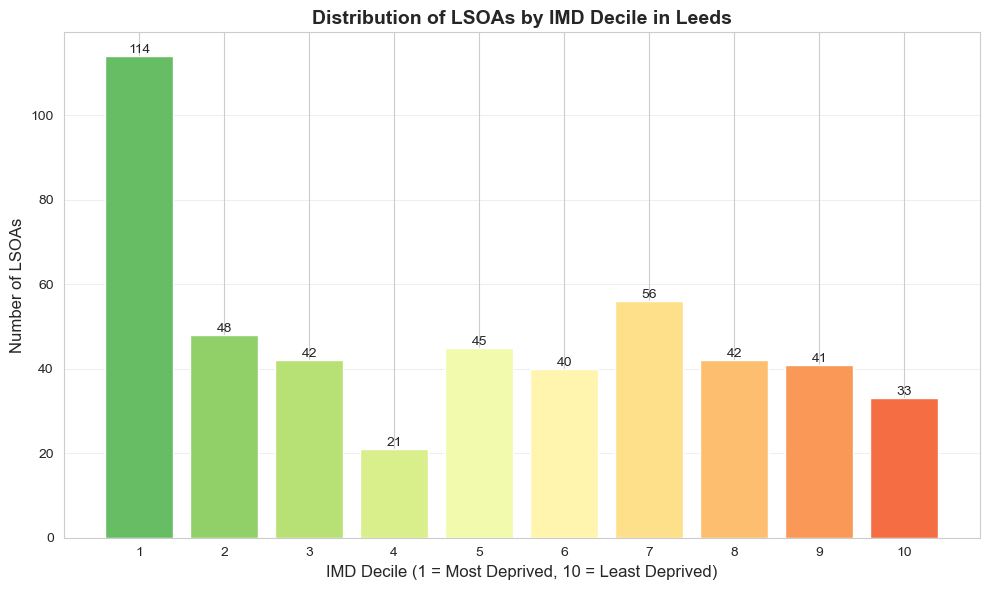

In [7]:
# IMD Decile Bar Chart
if decile_col:
    decile_counts = leeds_df[decile_col].value_counts().sort_index()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(decile_counts.index, decile_counts.values, 
                  color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(decile_counts))))
    
    ax.set_xlabel('IMD Decile (1 = Most Deprived, 10 = Least Deprived)', fontsize=12)
    ax.set_ylabel('Number of LSOAs', fontsize=12)
    ax.set_title('Distribution of LSOAs by IMD Decile in Leeds', fontsize=14, fontweight='bold')
    ax.set_xticks(decile_counts.index)
    ax.grid(axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FOLDER, 'imd_decile_bar_chart.png'), dpi=300, bbox_inches='tight')
    plt.show()

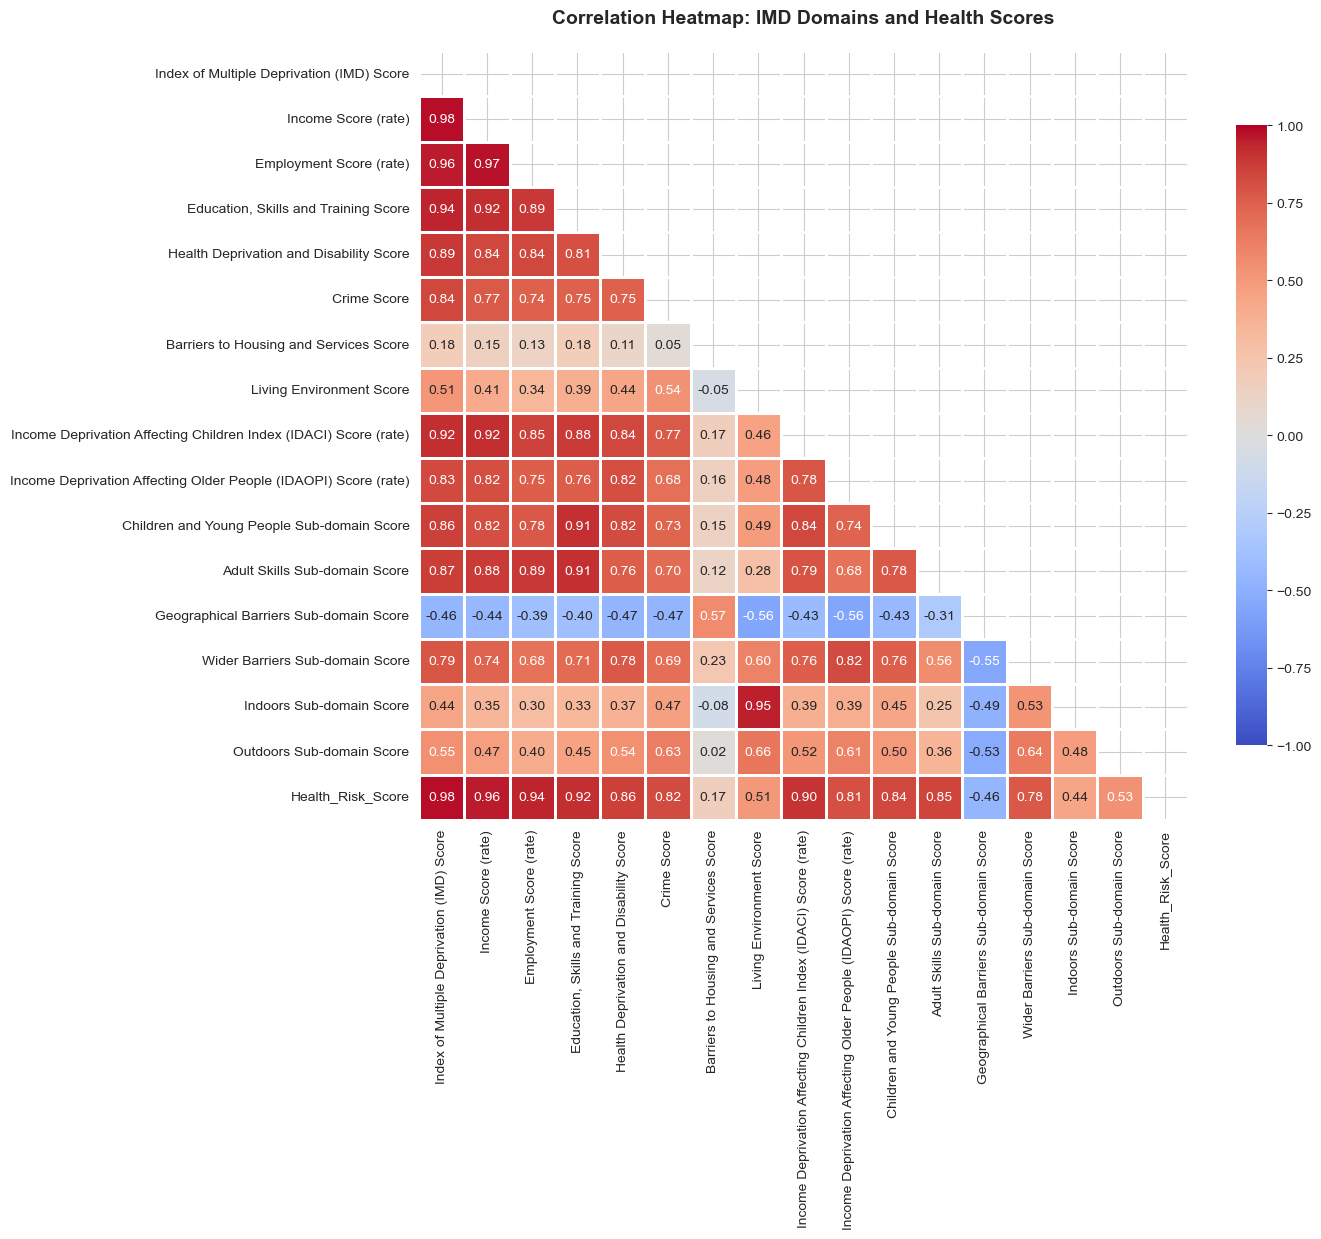

In [8]:
# Correlation Heatmap
score_cols = [col for col in leeds_df.columns if 'score' in col.lower() and leeds_df[col].dtype in [np.float64, np.int64]]

if len(score_cols) >= 2:
    corr_matrix = leeds_df[score_cols].corr()
    
    fig, ax = plt.subplots(figsize=(14, 12))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
                ax=ax, vmin=-1, vmax=1)
    
    ax.set_title('Correlation Heatmap: IMD Domains and Health Scores', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FOLDER, 'correlation_heatmap.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    # Save correlation matrix
    corr_matrix.to_csv(os.path.join(OUTPUT_FOLDER, 'correlation_matrix.csv'))

## Step 5: Statistical Analysis

In [9]:
# Identify Top 10 At-Risk LSOAs
print("=" * 60)
print("TOP 10 AT-RISK LSOAs")
print("=" * 60)

# Normalize scores
imd_values = leeds_df[imd_score_col].fillna(leeds_df[imd_score_col].median())
imd_normalized = (imd_values - imd_values.min()) / (imd_values.max() - imd_values.min())

health_values = leeds_df['Health_Risk_Score'].fillna(leeds_df['Health_Risk_Score'].median())
health_normalized = (health_values - health_values.min()) / (health_values.max() - health_values.min())

leeds_df['Composite_Risk_Score'] = (imd_normalized + health_normalized) / 2

# Find LSOA identifier
lsoa_id_col = None
for col in leeds_df.columns:
    if 'lsoa' in col.lower() and ('code' in col.lower() or 'name' in col.lower()):
        lsoa_id_col = col
        break

# Get top 10
at_risk = leeds_df.nlargest(10, 'Composite_Risk_Score').copy()

output_cols = [lsoa_id_col, imd_score_col, 'Health_Risk_Score', 'Composite_Risk_Score'] if lsoa_id_col else [imd_score_col, 'Health_Risk_Score', 'Composite_Risk_Score']
output_cols.extend(['Obesity_Percent', 'Diabetes_Percent', 'Life_Expectancy'])
output_cols = [col for col in output_cols if col in at_risk.columns]

at_risk_output = at_risk[output_cols]
print("\nTop 10 At-Risk LSOAs:")
print(at_risk_output.to_string(index=False))

# Save
at_risk_output.to_csv(os.path.join(OUTPUT_FOLDER, 'top_at_risk_lsoas.csv'), index=False)
print(f"\nSaved to {os.path.join(OUTPUT_FOLDER, 'top_at_risk_lsoas.csv')}")

TOP 10 AT-RISK LSOAs

Top 10 At-Risk LSOAs:
LSOA code (2011)  Index of Multiple Deprivation (IMD) Score  Health_Risk_Score  Composite_Risk_Score  Obesity_Percent  Diabetes_Percent  Life_Expectancy
       E01011372                                     78.577           0.891342              0.995080        34.158709         14.270693        77.440165
       E01011368                                     75.543           0.898983              0.980184        34.927636         12.866333        76.734255
       E01011363                                     73.670           0.847002              0.934479        33.254318         11.786931        78.528191
       E01011662                                     77.034           0.797084              0.924306        34.746689         11.221525        78.154956
       E01011375                                     73.056           0.824481              0.915967        33.595657         11.035813        78.054622
       E01011625                      

## Step 6: Generate Insights Report

In [10]:
# Generate insights report
report_path = os.path.join(OUTPUT_FOLDER, 'insights_report.txt')

with open(report_path, 'w') as f:
    f.write("=" * 80 + "\n")
    f.write("LEEDS HEALTH INEQUALITIES PROJECT - INSIGHTS REPORT\n")
    f.write("=" * 80 + "\n\n")
    
    f.write("KEY FINDINGS\n")
    f.write("-" * 80 + "\n")
    f.write(f"• Total LSOAs analyzed: {len(leeds_df)}\n")
    
    if decile_col:
        most_deprived = len(leeds_df[leeds_df[decile_col].isin([1, 2, 3])])
        pct = (most_deprived / len(leeds_df)) * 100
        f.write(f"• {pct:.1f}% of LSOAs are in the most deprived deciles (1-3)\n")
    
    f.write(f"• Mean IMD Score: {leeds_df[imd_score_col].mean():.2f}\n")
    f.write(f"• Mean Life Expectancy: {leeds_df['Life_Expectancy'].mean():.1f} years\n")
    f.write(f"• Mean Obesity Rate: {leeds_df['Obesity_Percent'].mean():.1f}%\n")
    
    f.write("\nPOLICY RECOMMENDATIONS\n")
    f.write("-" * 80 + "\n")
    f.write("1. Focus resources on LSOAs in IMD deciles 1-3\n")
    f.write("2. Address multiple deprivation domains simultaneously\n")
    f.write("3. Establish regular monitoring of health outcomes\n")
    f.write("4. Involve residents in designing interventions\n")

print(f"Insights report saved to {report_path}")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)
print(f"\nAll outputs saved to '{OUTPUT_FOLDER}' folder:")
print(f"  • Cleaned data: {cleaned_file}")
print(f"  • Data with health indicators: {health_file}")
print(f"  • Visualizations: {OUTPUT_FOLDER}")
print(f"  • Insights report: {report_path}")
print(f"  • Top at-risk LSOAs: {os.path.join(OUTPUT_FOLDER, 'top_at_risk_lsoas.csv')}")

Insights report saved to output\insights_report.txt

ANALYSIS COMPLETE!

All outputs saved to 'output' folder:
  • Cleaned data: output\Leeds_IMD_LSOA.csv
  • Data with health indicators: output\Leeds_IMD_with_Health.csv
  • Visualizations: output
  • Insights report: output\insights_report.txt
  • Top at-risk LSOAs: output\top_at_risk_lsoas.csv
